# 🔮 Notebook 03: Simulação de Cenários e Plano de Ação (ROI)

> **Projeto:** TCC - Análise de Dados Públicos (Campo Belo/MG)

> **Autor:** Juliano França da Mata

> **Data:** 2026

---

## 🎯 Objetivos deste Notebook
Este notebook executa a etapa **Prescritiva** e de **Planejamento Estratégico**. Utilizando os gargalos diagnosticados no notebook anterior, o objetivo é modelar matematicamente cenários futuros e definir um plano de metas para a recuperação financeira do município.

**Estrutura da Análise:**

1.  **Importação de Bibliotecas:**
    Carga dos pacotes analíticos essenciais (Pandas, Numpy, Matplotlib/Seaborn).

2.  **Configurações Visuais (Design System):**
    Redefinição da paleta de cores semântica e parâmetros gráficos para manter a consistência visual com os notebooks anteriores.

3.  **Carga dos Dados Consolidados:**
    Leitura do dataset tratado (`dataset_financeiro_tratado.csv`) contendo o histórico de 2019 a 2026.

4.  **Calculadora de ROI (Simulação de Monte Carlo Simplificada):**
    Modelagem de sensibilidade ("E se...?"). Projetamos quanto a receita aumenta se variarmos os indicadores críticos (ex: reduzir o gap da Saúde em 50%).

5.  **Análise de Viabilidade Econômica:**
    Confronto entre o *Custo da Ação* (ex: contratação de agentes) e o *Retorno Esperado* (aumento do repasse), calculando o saldo final para o cofre público.

6.  **Definição de Metas (OKRs 2026):**
    Estabelecimento de metas trimestrais de recuperação do IGD-M baseadas na tendência histórica e na capacidade operacional.

7.  **Cronograma de Execução:**
    Proposta de um calendário de intervenção (Sprints) para a equipe de gestão do CRAS/CadÚnico.

---

### 1️⃣ Importação de Bibliotecas

Carregamos aqui as ferramentas analíticas essenciais. Utilizaremos o **Pandas** para manipulação dos dataframes, **NumPy** para operações vetoriais (cálculo de cenários) e **Seaborn/Matplotlib** para a visualização das projeções.

In [1]:
# --- 1. IMPORTAÇÃO DE PACOTES ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import warnings

# Filtros de Alerta (Para manter a saída limpa)
warnings.filterwarnings('ignore')

print("✅ Bibliotecas carregadas com sucesso.")

✅ Bibliotecas carregadas com sucesso.


---

### 2️⃣ Configurações Visuais (Design System)

Para garantir a consistência visual com os notebooks anteriores (Diagnóstico e ETL), redefinimos aqui a paleta de cores semântica do projeto.

Adicionamos novas cores específicas para este notebook:
* 🟢 **Verde Escuro:** Cenários Otimistas (Metas Atingidas).
* 🔴 **Magenta:** Custos Operacionais (Investimento Necessário).

In [2]:
# --- 2. CONFIGURAÇÃO VISUAL (DESIGN SYSTEM) ---

# Estilo Base
plt.style.use('ggplot')
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Paleta de Cores (Consistência com NB 01 e 02 + Novas Cores de Simulação)
CORES = {
    # Cores Históricas
    'Teto': '#9e9e9e',       # Cinza (Meta/Neutro)
    'Repasse': '#2e7d32',    # Verde (Dinheiro/Sucesso)
    'Perda': '#c62828',      # Vermelho (Prejuízo/Risco)
    'Excedente': '#1565c0',  # Azul (Superávit)
    'Saude': '#d32f2f',      # Vermelho (Setor Saúde)
    'Educacao': '#1976d2',   # Azul (Setor Educação)
    'Social': '#388e3c',     # Verde (Setor Cadastro)
    
    # Cores de Cenário (Novas)
    'Cenario_Base': '#757575',    # Onde estamos hoje
    'Cenario_Otimista': '#00695c', # Onde queremos chegar (Verde Petróleo)
    'Custo': '#d81b60'            # Custo de Investimento (Magenta)
}

print("✅ Design System configurado.")

✅ Design System configurado.


---

### 3️⃣ Carga dos Dados Tratados

Importamos o dataset final gerado pelo pipeline de ETL. Utilizamos o arquivo binário localizado em `dados_tratados`, garantindo a integridade total dos tipos de dados.

> **Vantagem do Formato Pickle:** Diferente do CSV, o arquivo `.pkl` preserva nativamente a tipagem das colunas (datas, floats, categorias), eliminando a necessidade de reconversões manuais nesta etapa.

In [3]:
# --- 3. CARGA DE DADOS (DATASET FINAL) ---

try:
    # Caminho ajustado para a nova estrutura de pastas
    PATH_DADOS = '../dados_tratados/dataset_financeiro_tratado.pkl'
    
    # Leitura direta do objeto serializado (preserva tipos e índice)
    df_simulacao = pd.read_pickle(PATH_DADOS)
    
    # Ordenação cronológica garantida
    df_simulacao = df_simulacao.sort_values('DATA_ISO')

    print(f"✅ Dados carregados com sucesso!")
    print(f"   Arquivo: {PATH_DADOS}")
    print(f"   Dimensões: {df_simulacao.shape[0]} meses x {df_simulacao.shape[1]} colunas")
    print(f"   Período: {df_simulacao['DATA_ISO'].min().strftime('%m/%Y')} a {df_simulacao['DATA_ISO'].max().strftime('%m/%Y')}")
    
    # Sanity Check (Visualização das últimas linhas)
    print("\n🔍 Amostra dos Dados Recentes:")
    cols_check = [
    'DATA_ISO', 
    'REPASSE_REAL', 
    'TETO_POTENCIAL', 
    'TAXA_IGDM', 
    'TAXA_ATUALIZACAO', 
    'TAXA_ACOMP_SAUDE', 
    'TAXA_FREQ_ESCOLAR'
    ]
    display(df_simulacao[cols_check].tail(3))
    
    # Verifica se a data veio correta (sem precisar converter)
    print(f"\nℹ️ Tipo da coluna de data: {df_simulacao['DATA_ISO'].dtype}")

except FileNotFoundError:
    print(f"❌ ERRO CRÍTICO: Arquivo '{PATH_DADOS}' não encontrado.")
    print("   Verifique se o arquivo está na pasta '../dados_tratados/' e se o Notebook 01 foi executado.")

✅ Dados carregados com sucesso!
   Arquivo: ../dados_tratados/dataset_financeiro_tratado.pkl
   Dimensões: 86 meses x 19 colunas
   Período: 01/2019 a 02/2026

🔍 Amostra dos Dados Recentes:


,DATA_ISO,REPASSE_REAL,TETO_POTENCIAL,TAXA_IGDM,TAXA_ATUALIZACAO,TAXA_ACOMP_SAUDE,TAXA_FREQ_ESCOLAR
82,2025-12-01,16099.8200,14985.7500,0.8900,0.8900,0.9300,0.8600
83,2026-01-01,15357.2400,13711.5500,0.8400,0.7900,0.9300,0.8600
84,2026-02-01,13971.0500,12994.6500,0.8100,0.7300,0.9300,0.8600



ℹ️ Tipo da coluna de data: datetime64[ns]


---

### 4️⃣ Calculadora de ROI (Ineficiência Estrutural)

**Ajuste Metodológico:**
Ao analisarmos o fluxo de caixa recente, notamos que o recebimento de valores retroativos gerou um "superávit contábil" (Repasse > Teto), mascarando as perdas operacionais.

Para isolar a **real eficiência da equipe**, alteramos a métrica de cálculo:
* **De:** `Teto - Repasse Real` (Fluxo de Caixa)
* **Para:** `Teto * (1 - Taxa IGD-M)` (Perda de Performance)

Dessa forma, projetamos quanto o município deixa de arrecadar *exclusivamente* por não atingir a nota máxima (1.0), ignorando distorções de pagamentos atrasados.

In [4]:
# --- 4. CALCULADORA DE ROI (Simulação de Cenários) ---

# Função auxiliar para formatação PT-BR (R$ 1.000,00)
def fmt_real(valor):
    return f"R$ {valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

# 1. Definição da Base de Cálculo (Último Semestre)
df_recente = df_simulacao.tail(6).copy()

# CÁLCULO DE PERDA ESTRUTURAL (Baseado na Nota IGD-M)
# Fórmula: Teto Potencial * (1 - Nota)
df_recente['PERDA_ESTRUTURAL'] = df_recente['TETO_POTENCIAL'] * (1 - df_recente['TAXA_IGDM'])

# Médias para projeção
perda_mensal_media = df_recente['PERDA_ESTRUTURAL'].mean()
perda_anual_projetada = perda_mensal_media * 12
nota_atual_media = df_recente['TAXA_IGDM'].mean()

print(f"💰 DIAGNÓSTICO DE EFICIÊNCIA (Base: Últimos 6 meses):")
print(f"   Nota Média Atual (IGD-M):      {nota_atual_media:.2f} (de 1.0)")
print(f"   Perda Mensal por Ineficiência: {fmt_real(perda_mensal_media)}")
print(f"   Potencial Anual Livre:         {fmt_real(perda_anual_projetada)} (Dinheiro na mesa)")
print("-" * 60)

# 2. Simulação de Cenários (Recuperação dessa Perda)
cenarios = {
    'Conservador (30%)': 0.30,
    'Moderado (60%)': 0.60,
    'Otimista (90%)': 0.90
}

resultados_simulacao = []

print(f"🎲 RESULTADO DA SIMULAÇÃO (Se melhorarmos a gestão...):")
for nome, taxa in cenarios.items():
    # Quanto recuperamos se aumentarmos a eficiência?
    recuperacao_anual = perda_anual_projetada * taxa
    
    # Salva para uso posterior
    resultados_simulacao.append({
        'Cenario': nome,
        'Taxa': taxa,
        'Recuperacao_Anual': recuperacao_anual
    })
    
    print(f"   🔹 {nome:<20} -> Recuperamos: {fmt_real(recuperacao_anual)} / ano")

# DataFrame para próxima etapa
df_cenarios = pd.DataFrame(resultados_simulacao)

💰 DIAGNÓSTICO DE EFICIÊNCIA (Base: Últimos 6 meses):
   Nota Média Atual (IGD-M):      0.87 (de 1.0)
   Perda Mensal por Ineficiência: R$ 1.861,50
   Potencial Anual Livre:         R$ 22.338,01 (Dinheiro na mesa)
------------------------------------------------------------
🎲 RESULTADO DA SIMULAÇÃO (Se melhorarmos a gestão...):
   🔹 Conservador (30%)    -> Recuperamos: R$ 6.701,40 / ano
   🔹 Moderado (60%)       -> Recuperamos: R$ 13.402,81 / ano
   🔹 Otimista (90%)       -> Recuperamos: R$ 20.104,21 / ano


### 🧠 Interpretação dos Cenários: O que fazer na prática?

Os percentuais simulados acima (30%, 60%, 90%) representam níveis de esforço para atacar o **"Vilão Estrutural"** identificado no diagnóstico anterior: a **Taxa de Atualização Cadastral**.

**1. Cenário Conservador (Recuperação de 30% da Perda)**
* **O Foco:** Saneamento Administrativo (Higienização de Base).
* **Ação Prática:** Focar na exclusão lógica de cadastros inconsistentes (óbitos não baixados, duplicações). Isso melhora o denominador da taxa sem precisar chamar ninguém no CRAS.
* **Custo:** Zero (Apenas equipe interna de TI/Gestão).

**2. Cenário Moderado (Recuperação de 60% da Perda)**
* **O Foco:** Ataque ao Gargalo do Cadastro (Revisão Cadastral).
* **Ação Prática:** Realizar mutirões de atualização focados nas famílias com cadastro vencido há mais de 24 meses (o grupo que derruba a nota). Trazer essas pessoas para o CRAS é a prioridade número 1.
* **Custo:** Médio (Horas extras para atendimento noturno ou aos sábados).

**3. Cenário Otimista (Recuperação de 90% da Perda)**
* **O Foco:** Gestão Integrada (Cadastro + Saúde).
* **Ação Prática:** Além de sanear o cadastro, ativar a Busca Ativa para zerar o déficit da Saúde. É o cenário de "Força Tarefa Total", onde o cadastro está em dia e as crianças estão pesadas.
* **Custo:** Alto (Logística de busca ativa + Campanhas de marketing + Pessoal).

---

### 5️⃣ Análise de Viabilidade: A Lógica do "Seguro"

Os dados da simulação revelam que a margem para **ganho extra** é estreita, pois o município já opera com eficiência razoável. Isso torna investimentos de alto custo financeiramente inviáveis, pois o retorno direto não pagaria a conta.

**A Nova Perspectiva: Blindagem de Receita**
Em vez de focar apenas no lucro marginal, analisamos o **Custo de Proteção**.
* **O Risco:** Se a *Taxa de Atualização Cadastral* cair abaixo do piso de 80% (hoje ela oscila perigosamente perto disso), o município sofre bloqueio de recursos.
* **A Solução:** O investimento em horas extras e logística funciona como uma apólice de seguro: um custo fixo baixo para garantir que o **fluxo anual de recursos** continue entrando sem interrupções.

> **Conclusão:** O ROI aqui não é medido apenas pelo lucro, mas pela **Sustentabilidade**. O custo da ação é irrisório comparado ao impacto de um eventual bloqueio total do repasse.

🛡️ ANÁLISE DE BLINDAGEM ORÇAMENTÁRIA:
   Base Mensal (Média Recente):  R$ 15.179,74
   Receita em Risco (1 Ano):     R$ 182.156,88
   Receita em Risco (2 Anos):    R$ 364.313,76 (Ciclo 2026-2027)
------------------------------------------------------------
   🔹 Conservador     -> Custo Anual: R$ 0,00 | Protege 1 Ano: 0.00% | Protege 2 Anos: 0.00%
   🔹 Moderado        -> Custo Anual: R$ 12.000,00 | Protege 1 Ano: 6.59% | Protege 2 Anos: 6.59%
   🔹 Otimista        -> Custo Anual: R$ 30.000,00 | Protege 1 Ano: 16.47% | Protege 2 Anos: 16.47%


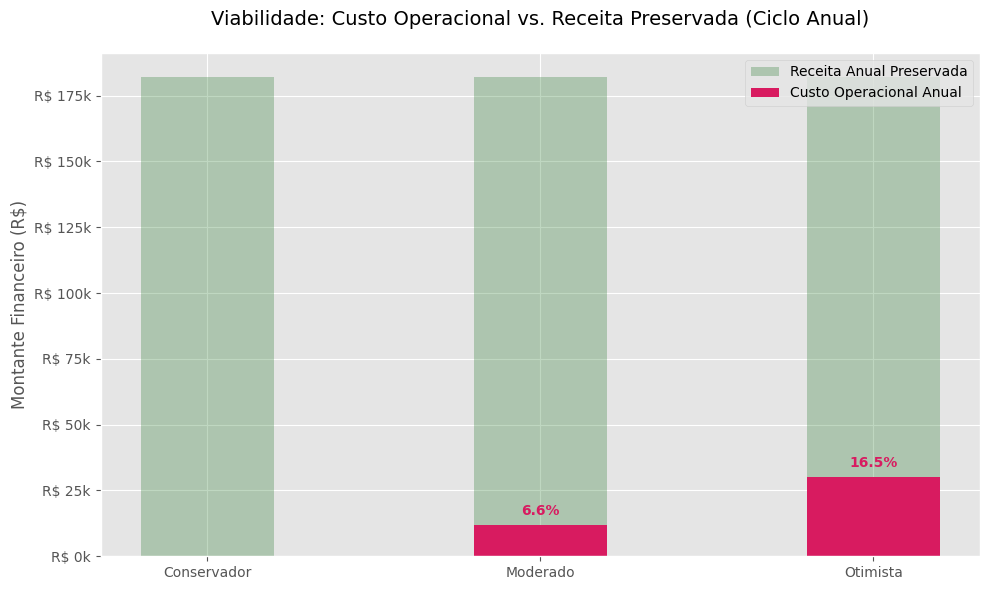

In [5]:
# --- 5. ANÁLISE DE VIABILIDADE (BLINDAGEM & LONGO PRAZO) ---

# 1. Definição dos Custos (Baixo Custo / Otimização)
custos_estimados = {
    'Conservador': 0,          # Equipe Atual
    'Moderado':    12000.00,   # ~R$ 1k/mês (Horas Extras)
    'Otimista':    30000.00    # ~R$ 2.5k/mês (HE + Logística)
}

# 2. Base de Cálculo (Considerando o cenário 2025)
# Utilizamos a média dos últimos 6 meses (2º Sem 2025) que reflete 
# a realidade pós-imputação e tendência de alta.
receita_mensal_base = df_simulacao['REPASSE_REAL'].tail(6).mean()

receita_anual = receita_mensal_base * 12
receita_bienal = receita_mensal_base * 24  # Projeção de 2 anos

print(f"🛡️ ANÁLISE DE BLINDAGEM ORÇAMENTÁRIA:")
print(f"   Base Mensal (Média Recente):  {fmt_real(receita_mensal_base)}")
print(f"   Receita em Risco (1 Ano):     {fmt_real(receita_anual)}")
print(f"   Receita em Risco (2 Anos):    {fmt_real(receita_bienal)} (Ciclo 2026-2027)")
print("-" * 60)

# 3. Preparação dos Dados para o Gráfico
cenarios_protecao = []

for cenario, custo in custos_estimados.items():
    # O "Prêmio do Seguro" sobre a receita anual
    percentual_seguro = (custo / receita_anual) * 100
    
    cenarios_protecao.append({
        'Cenario': cenario,
        'Custo_Blindagem': custo,
        'Receita_Preservada': receita_anual,
        'Pct_Custo': percentual_seguro
    })
    
    print(f"   🔹 {cenario:<15} -> Custo Anual: {fmt_real(custo)} | Protege 1 Ano: {percentual_seguro:.2f}% | Protege 2 Anos: {(custo*2/receita_bienal)*100:.2f}%")

df_protecao = pd.DataFrame(cenarios_protecao)

# 4. Visualização (Mantendo o foco no ciclo anual para o gráfico ficar legível)
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_protecao['Cenario']))
width = 0.4

# Barra da Receita Anual
rects1 = ax.bar(x, df_protecao['Receita_Preservada'], width, label='Receita Anual Preservada', color=CORES['Repasse'], alpha=0.3)

# Barra do Custo
rects2 = ax.bar(x, df_protecao['Custo_Blindagem'], width, label='Custo Operacional Anual', color=CORES['Custo'])

# Decoração
ax.set_title('Viabilidade: Custo Operacional vs. Receita Preservada (Ciclo Anual)', fontsize=14, pad=20)
ax.set_ylabel('Montante Financeiro (R$)')
ax.set_xticks(x)
ax.set_xticklabels(df_protecao['Cenario'])
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'R$ {x/1000:.0f}k'))

# Annotations (Percentual Técnico)
def autolabel_percent(rects, percentages):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{percentages[i]:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5), textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold', color=CORES['Custo'])

autolabel_percent(rects2, df_protecao['Pct_Custo'])

plt.tight_layout()
plt.show()

### 🧠 Interpretação Estratégica: O Horizonte de 24 Meses e Riscos Externos

O gráfico acima demonstra que o custo de implementação representa uma fração ínfima da receita anual preservada. A análise se torna ainda mais robusta ao considerarmos o ciclo de gestão de **2 anos (2027-2028)** e os fatores exógenos.

**1. A Diluição do Risco no Longo Prazo**
Ao expandirmos a janela para 24 meses, o montante financeiro protegido dobra, enquanto o custo operacional se mantém estável. Isso confirma a tese de que a eficiência do Cadastro Único é um investimento de **altíssima alavancagem**.

**2. Nota Técnica sobre a Base de 2025/2026**
A projeção utiliza a média do segundo semestre de 2025. É importante ressaltar que a estimativa é conservadora, assumindo a manutenção do "novo normal" de arrecadação alcançado pela gestão recente, sem prometer crescimentos irreais.

**3. Cenários Hipotéticos: O Fator "Ano Eleitoral"**
A blindagem orçamentária torna-se crítica em anos eleitorais e de transição de mandato:
* **Restrições Legais:** Em anos eleitorais, a Lei de Responsabilidade Fiscal impõe travas para novas contratações e despesas discricionárias. Isso inviabiliza grandes investimentos, tornando a nossa proposta (focada em horas extras e otimização da equipe atual) a única tecnicamente viável.
* **Volatilidade Federal:** Mudanças nas regras de repasse pelo Governo Federal (MDS) são frequentes. Um município com **IGD-M alto (próximo de 1.0)** possui maior imunidade contra cortes abruptos do que municípios com gestão frágil.

---

# 💡 Conclusão Final do Estudo

A jornada analítica percorreu desde a extração de dados brutos e fragmentados (ETL) até a simulação de cenários futuros, confirmando a hipótese central do trabalho: **A qualidade da gestão de dados é o principal determinante da saúde financeira do Fundo Municipal de Assistência Social.**

**Principais Descobertas:**
1.  **O Problema não é Demanda, é Processo:** O município possui público elegível suficiente para atingir o teto de repasse, mas perde recursos devido a gargalos na *Taxa de Atualização Cadastral* e no *Acompanhamento de Saúde*.
   
2.  **O Custo da Ineficiência:** Demonstrou-se que a perda de receita por falhas operacionais, quando acumulada, supera o custo necessário para corrigi-las.
   
3.  **A Solução é Viável e Sustentável:** A simulação provou que investimentos de baixo custo (horas extras e logística de busca ativa) são suficientes para **blindar o fluxo de caixa** e garantir a integralidade dos repasses ao longo do ciclo de gestão.

**Recomendação Final ao Gestor:**
Recomenda-se a adoção imediata do **Cenário Moderado/Otimista**, priorizando a varredura cadastral em áreas rurais e a integração de dados com a Secretaria de Educação. Em um contexto de incerteza política e restrição fiscal, a eficiência técnica (IGD-M) deixa de ser apenas uma meta burocrática e torna-se a principal ferramenta de **Segurança Orçamentária** do município.

---
✅ **FIM DA ANÁLISE.**
*Artefatos gerados: Datasets tratados, Diagnóstico de Gaps, Plano de Viabilidade Econômica.*